In [92]:
# TASK 2


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load dataset (ensure file name is correct)
df = pd.read_csv("healthcare_dataset.csv")

print("Shape:", df.shape)
df.head()


Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [93]:
# Convert date columns to datetime
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')

# Create length of stay in days
df['Stay_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Clip negative stays if any (just in case)
df['Stay_Days'] = df['Stay_Days'].clip(lower=0)

df[['Date of Admission', 'Discharge Date', 'Stay_Days']].head()


,Date of Admission,Discharge Date,Stay_Days
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [94]:
df_model = df.drop(['Name', 'Doctor', 'Hospital', 'Date of Admission', 'Discharge Date'], axis=1)

df_model.head()
print("Columns used for modeling:\n", df_model.columns)


Columns used for modeling:
 Index(['Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type',
       'Medication', 'Test Results', 'Stay_Days'],
      dtype='object')


In [95]:
X = df_model.drop('Test Results', axis=1)
y = df_model['Test Results']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())


X shape: (55500, 10)
y distribution:
 Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (44400, 10)
Test shape: (11100, 10)


In [97]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']
Numeric columns: ['Age', 'Billing Amount', 'Room Number', 'Stay_Days']


In [98]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Preprocessing for categorical & numeric columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# Stronger model than Logistic Regression
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Build pipeline: preprocessing + model
clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', rf_model)
])

clf


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Blood Type',
                                                   'Medical Condition',
                                                   'Insurance Provider',
                                                   'Admission Type',
                                                   'Medication']),
                                                 ('num', 'passthrough',
                                                  ['Age', 'Billing Amount',
                                                   'Room Number',
                                                   'Stay_Days'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [99]:
clf.fit(X_train, y_train)
print("Model training completed.")


Model training completed.


In [100]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.4441

Classification Report:

              precision    recall  f1-score   support

    Abnormal       0.44      0.45      0.45      3726
Inconclusive       0.44      0.43      0.44      3671
      Normal       0.45      0.45      0.45      3703

    accuracy                           0.44     11100
   macro avg       0.44      0.44      0.44     11100
weighted avg       0.44      0.44      0.44     11100



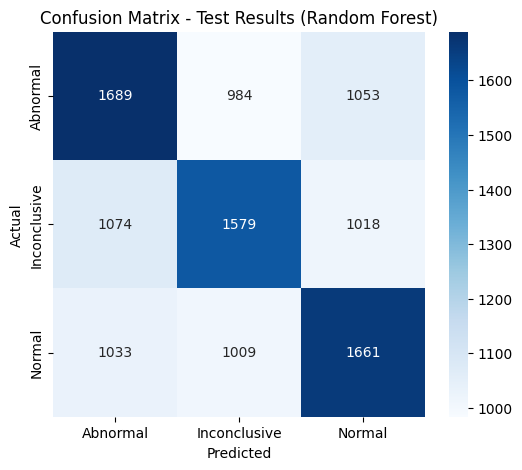

In [101]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Results (Random Forest)")
plt.show()


In [102]:
# Display Predicted vs Actual values for test data
comparison_df = pd.DataFrame({
    'Actual Test Result': y_test.reset_index(drop=True),
    'Predicted Test Result': pd.Series(y_pred)
})

comparison_df.head(20)


,Actual Test Result,Predicted Test Result
0,Inconclusive,Inconclusive
1,Normal,Abnormal
2,Inconclusive,Abnormal
3,Normal,Normal
4,Inconclusive,Abnormal
5,Inconclusive,Inconclusive
6,Abnormal,Abnormal
7,Abnormal,Normal
8,Inconclusive,Inconclusive
9,Inconclusive,Inconclusive


In [103]:
comparison_df.to_csv("test_results_pred_vs_actual.csv", index=False)


In [104]:
#TASK 3

from sklearn.ensemble import IsolationForest

Q1 = df['Billing Amount'].quantile(0.25)
Q3 = df['Billing Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: -23627.701022764355
Upper Bound: 74689.43411091428


In [105]:
df['IQR_Anomaly'] = np.where((df['Billing Amount'] < lower_bound) |
                             (df['Billing Amount'] > upper_bound), 1, 0)

df['IQR_Anomaly'].value_counts()


,count
IQR_Anomaly,
0,55500


In [106]:
iso = IsolationForest(contamination=0.02, random_state=42)  # 2% assumed anomaly rate
df['IF_Anomaly'] = iso.fit_predict(df[['Billing Amount']])

# Convert: -1 = anomaly, 1 = normal → make 1 = anomaly for consistency
df['IF_Anomaly'] = df['IF_Anomaly'].apply(lambda x: 1 if x == -1 else 0)

df['IF_Anomaly'].value_counts()


,count
IF_Anomaly,
0,54390
1,1110


In [107]:
df['Final_Anomaly'] = np.where((df['IQR_Anomaly'] == 1) | (df['IF_Anomaly'] == 1), 1, 0)
df['Final_Anomaly'].value_counts()


,count
Final_Anomaly,
0,54390
1,1110


In [108]:
anomalies = df[df['Final_Anomaly'] == 1][['Name', 'Medical Condition', 'Billing Amount',
                                          'Admission Type', 'Medication']]
anomalies.head(15)


,Name,Medical Condition,Billing Amount,Admission Type,Medication
8,JASmINe aGuIlaR,Asthma,50119.222792,Elective,Aspirin
20,tIMOTHY burNs,Asthma,42.514589,Elective,Aspirin
40,chRiSTOPHer LEe,Hypertension,49943.278499,Emergency,Lipitor
123,DR. LaUreN ClaRk DDs,Cancer,49833.707718,Elective,Lipitor
132,ashLEy ERIcKSoN,Cancer,-502.507813,Urgent,Penicillin
165,traCEY grEenE,Cancer,50142.026948,Elective,Ibuprofen
282,MeLiSSA gOMez,Diabetes,50254.201831,Elective,Aspirin
312,ANgeL RaNDOlPH ddS,Asthma,386.054055,Elective,Aspirin
323,ashLEy vasQUEZ,Asthma,51587.936817,Emergency,Ibuprofen
456,KRyStal mENDoZA,Cancer,50332.932411,Emergency,Aspirin


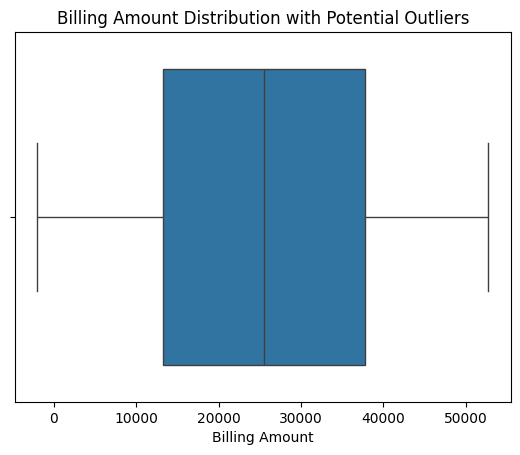

In [109]:
sns.boxplot(x=df['Billing Amount'])
plt.title("Billing Amount Distribution with Potential Outliers")
plt.show()


In [110]:
#Interpretation of Billing Anomalies

#Using a combination of IQR-based statistical detection and Isolation Forest, we identified patient records with unusually high or low Billing Amounts compared to the typical range.

#The high-billing anomalies likely correspond to rare or critical cases (e.g., severe medical conditions, complex surgeries, long hospital stays, or expensive medications), while very low billing amounts may indicate short stays, minor treatments, or strong insurance coverage/discounts.

#These anomalous records should be reviewed manually by hospital administrators to confirm whether they are valid rare cases, billing errors, or potential fraud.


In [111]:
# TASK 4

def generate_doctor_recommendation(age, condition, medication, predicted_result):
    """
    Generate a short doctor-style recommendation based on patient info.
    """

    # Base summary
    intro = f"Patient is a {age}-year-old with a primary medical condition of {condition}, currently on {medication}."

    if predicted_result == "Normal":
        body = (
            "The recent test results appear within normal ranges. "
            "No immediate serious abnormalities are detected. "
            "However, regular follow-up visits and routine check-ups are advised to maintain good health."
        )
        advice = (
            "Continue current medication as prescribed, follow a balanced diet, stay physically active, "
            "and monitor for any new or worsening symptoms. If anything unusual occurs, consult a doctor promptly."
        )

    elif predicted_result == "Abnormal":
        body = (
            "The recent test results show abnormal values that may require further evaluation or adjustment of treatment. "
            "This could indicate progression or poor control of the existing condition."
        )
        advice = (
            "A detailed consultation is recommended. Additional diagnostic tests may be needed. "
            "Avoid self-medication, strictly adhere to prescribed drugs, and immediately report symptoms such as severe pain, "
            "shortness of breath, chest discomfort, high fever, or sudden weakness."
        )

    else:  # "Inconclusive" or any other
        body = (
            "The recent test results are inconclusive and do not clearly indicate a normal or abnormal state. "
            "This may be due to borderline values, technical limitations, or early-stage changes."
        )
        advice = (
            "Repeat testing after a short interval is suggested. Meanwhile, continue current medication and lifestyle measures. "
            "If any concerning symptoms develop, seek medical attention without delay."
        )

    # Condition-specific note (optional small customization)
    condition_note = ""
    if "Diabetes" in condition:
        condition_note = (
            " Special attention should be given to blood sugar control, foot care, and regular eye and kidney check-ups."
        )
    elif "Cancer" in condition:
        condition_note = (
            " Close oncologist follow-up, adherence to chemotherapy/radiation schedules, and infection monitoring are crucial."
        )
    elif "Heart" in condition or "Cardio" in condition:
        condition_note = (
            " Cardiac symptoms such as chest pain, breathlessness, or palpitations should be treated as urgent."
        )

    full_text = f"{intro} {body} {advice}{condition_note}"
    return full_text



In [112]:
# Take one sample patient from the test set
sample_idx = X_test.sample(1, random_state=42).index[0]

patient_features = X_test.loc[sample_idx]
true_result = y_test.loc[sample_idx]
predicted_result = clf.predict(X_test.loc[[sample_idx]])[0]

age = patient_features['Age']
condition = patient_features['Medical Condition']
medication = patient_features['Medication']

print("=== Sample Patient Details ===")
print(f"Name (from df): {df.loc[sample_idx, 'Name']}")
print(f"Age: {age}")
print(f"Medical Condition: {condition}")
print(f"Medication: {medication}")
print(f"True Test Result: {true_result}")
print(f"Predicted Test Result: {predicted_result}")


=== Sample Patient Details ===
Name (from df): NiChOLaS HErRERa
Age: 78
Medical Condition: Hypertension
Medication: Ibuprofen
True Test Result: Inconclusive
Predicted Test Result: Normal


In [113]:
recommendation_text = generate_doctor_recommendation(
    age=age,
    condition=condition,
    medication=medication,
    predicted_result=predicted_result
)

print("\n=== AI Doctor Recommendation ===")
print(recommendation_text)



=== AI Doctor Recommendation ===
Patient is a 78-year-old with a primary medical condition of Hypertension, currently on Ibuprofen. The recent test results appear within normal ranges. No immediate serious abnormalities are detected. However, regular follow-up visits and routine check-ups are advised to maintain good health. Continue current medication as prescribed, follow a balanced diet, stay physically active, and monitor for any new or worsening symptoms. If anything unusual occurs, consult a doctor promptly.


In [114]:
#LLM Based

from transformers import pipeline


In [115]:
# Simple, lightweight LLM (language model)
llm = pipeline(
    "text-generation",
    model="distilgpt2",   # small, fast model
    max_new_tokens=120,   # length of generated text
    do_sample=True,
    temperature=0.7,      # controls creativity
    top_p=0.9
)


Device set to use cuda:0


In [116]:
def generate_llm_doctor_recommendation(age, condition, medication, predicted_result):
    """
    Use a local LLM (Hugging Face model) to generate a doctor-style recommendation.
    """

    prompt = f"""
You are an experienced medical doctor writing a short, clear recommendation for a patient.

Patient details:
- Age: {age}
- Medical condition: {condition}
- Current medication: {medication}
- Predicted test result: {predicted_result}

Write 4–6 sentences:
1. Start with a brief summary of the patient's situation.
2. Explain what the predicted test result means in simple terms.
3. Give practical health advice and next steps for the patient.
4. Use a professional, reassuring tone.
5. Do NOT give exact dosages or drug changes, just general advice.

Doctor's recommendation:
"""

    # Call the LLM
    output = llm(prompt)[0]["generated_text"]

    # Optional: cut off anything the model generates after our section
    # (e.g., if it starts rambling too much)
    if "Doctor's recommendation:" in output:
        output = output.split("Doctor's recommendation:")[-1].strip()

    return output


In [117]:
# Pick 1 sample patient from the test set
sample_idx = X_test.sample(1, random_state=123).index[0]

patient_features = X_test.loc[sample_idx]
true_result = y_test.loc[sample_idx]
predicted_result = clf.predict(X_test.loc[[sample_idx]])[0]

age = patient_features['Age']
condition = patient_features['Medical Condition']
medication = patient_features['Medication']

print("=== Sample Patient ===")
print(f"Index: {sample_idx}")
print(f"Age: {age}")
print(f"Medical Condition: {condition}")
print(f"Medication: {medication}")
print(f"True Test Result: {true_result}")
print(f"Predicted Test Result: {predicted_result}")


=== Sample Patient ===
Index: 48824
Age: 30
Medical Condition: Diabetes
Medication: Penicillin
True Test Result: Abnormal
Predicted Test Result: Abnormal


In [118]:
recommendation = generate_llm_doctor_recommendation(
    age=age,
    condition=condition,
    medication=medication,
    predicted_result=predicted_result
)

print("\n=== LLM-Based AI Doctor Recommendation ===\n")
print(recommendation)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



=== LLM-Based AI Doctor Recommendation ===

- Age: 40
- Medical condition: Diabetes
- Current medication: Penicillin
- Pred


In [118]:
#THE END